# Building a conv model

The structure is simple:

- Input: image with 3 channels

- One convolutional layer: represented by the first adapter

- One recurrent convolutional module: represented the first layer

- Global majority pooling: each channel in the convolutional block is converted to a single scalar, by taking the majority. This is an adapter.

- Recurrent fully connected: as usual

- Wout: as usual

## Notes:

Layers communicate in both directions. This architecture still avoids a conv2dTranspose (i still have to test it).

## Building the modules

In [2]:
import sys
print(sys.path)
import darnax
print(darnax.__file__)
print(dir(darnax.modules))

['/opt/anaconda3/envs/brainAI/lib/python311.zip', '/opt/anaconda3/envs/brainAI/lib/python3.11', '/opt/anaconda3/envs/brainAI/lib/python3.11/lib-dynload', '', '/opt/anaconda3/envs/brainAI/lib/python3.11/site-packages', '/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src']
/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src/darnax/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'conv', 'fully_connected', 'input_output', 'interfaces', 'recurrent']


In [1]:
import sys
sys.path.insert(0, '/Users/michelangelonardi/Desktop/Università/Master/Bocconi Master/Tesi/darnax/src')

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity


In [1]:
import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer

N_CHANNELS = 64
INPUT_KERNEL_SIZE = 7
RECUR_KERNEL_SIZE = 7

key = jax.random.PRNGKey(0)
key, model_keys = jax.random.split(key)
keys_net = jax.random.split(model_keys, 5)

input_to_hidden = Conv2D(
    in_channels=3,
    out_channels=N_CHANNELS,
    kernel_size=INPUT_KERNEL_SIZE,
    threshold=1.7,
    strength=1.0,
    key=keys_net[0],
    padding_mode='constant', 
)

recurrent_conv = Conv2DRecurrentDiscrete(
    channels=N_CHANNELS,
    kernel_size=RECUR_KERNEL_SIZE,
    groups=N_CHANNELS,
    j_d=0.9,
    threshold=1.7,
    padding_mode="constant",
    key=keys_net[1],
    lr = 1.0, 
    weight_decay= 0.0
)

pooling_forward = GlobalMajorityPooling(
    strength=1.0,
    axis=(1, 2)
)

unpooling_backward = GlobalUnpooling(
    strength=1.0,
    axis=(1, 2)
)

recurrent = RecurrentDiscrete(
    features=N_CHANNELS,
    j_d=0.9,
    threshold=1.7,
    key=keys_net[2],
)

wout = FullyConnected(
    in_features=N_CHANNELS,
    out_features=10,
    strength=1.0,
    threshold=1.7,
    key=keys_net[3],
)

wback = FrozenRescaledFullyConnected(
    in_features=10,
    out_features=N_CHANNELS,
    strength=1.0,
    threshold=0.0,
    key=keys_net[4],
)

## Layermap

In [2]:
from darnax.layer_maps.sparse import LayerMap

layer_map_dict = {

    # what speaks TO the first layer
    1: {
        0: input_to_hidden, # the input
        1: recurrent_conv, # itself through a recurrent convolution
        2: unpooling_backward, # the unpooling from the fully connected
    },

    # what speaks to the fully connected layer
    2: {
        1: pooling_forward, # the pooling from the convolutional layer
        2: recurrent, # itself through a recurrent connection
        3: wback, # the feedback from the output
    },

    # who speaks to the output
    3: {
        2: wout, # the output from the fully connected layer
        3: OutputLayer(), # the output layer itself, its just a placeholder
    }
}

layer_map = LayerMap.from_dict(layer_map_dict)

## State

In [3]:
from darnax.states.sequential import SequentialState

state = SequentialState(
    [
        (32, 32, 3), # the input shape
        (32, 32, N_CHANNELS), # the convolutional layer shape
        (N_CHANNELS,), # the fully connected layer shape
        (10,) # the output shape
    ]
)

## Orchestrator

In [4]:
from darnax.orchestrators.sequential import SequentialOrchestrator

orchestrator = SequentialOrchestrator(
    layers=layer_map,
)

## Importing the dataset (CIFAR)

In [105]:
from darnax.datasets.classification.cifar10 import Cifar10

data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2029478885,  578969423], dtype=uint32)

In [12]:
# In order to do something:
# first we take a batch of data and we standardize it

x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

# then we initialize the state
state = state.init(x, y)

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


In [13]:
x.shape

(32, 32, 32, 3)

In [19]:
# then we can do a forward pass

key, forward_key = jax.random.split(key)

# this does a single step of the dynamics, it does not compute messages coming from labels
# it can be seen as the warmup 
state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")
#state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")

for _ in range(5):
    # this does the same, but computes all messages (clamped phase)
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="all")


for _ in range(5):
    # free phase
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")

In [32]:
state

SequentialState(
  states=[f32[32,32,32,3], f32[32,32,32,64], f32[32,64], f32[32,10]],
  dtype=jax.numpy.float32
)

## Analysis

### Correlations

In [166]:
key, forward_key = jax.random.split(key)
states_history = []

state = SequentialState([(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)])
state = state.init(x, y)

state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")

states_history.append(state)

for _ in range(5):
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="all")
    states_history.append(state)

for _ in range(5):
    state, forward_key = orchestrator.step(state, rng=forward_key, filter_messages="inference")
    states_history.append(state)


In [102]:
def compute_correlation_matrix(states_history, layer_idx=1, batch_idx=None):

    n_timesteps = len(states_history)
    corr_matrix = np.zeros((n_timesteps, n_timesteps))
    
    for i in range(n_timesteps):
        for j in range(i, n_timesteps):
            state_i = states_history[i].states[layer_idx]
            state_j = states_history[j].states[layer_idx]
            
            # Flatten both states to (batch, features)
            s_i = state_i.reshape(state_i.shape[0], -1)
            s_j = state_j.reshape(state_j.shape[0], -1)
            
            if batch_idx is not None:
                # Single image: correlate just that image's features
                corr, _ = pearsonr(s_i[batch_idx], s_j[batch_idx])
                corr_matrix[i, j] = corr
                corr_matrix[j, i] = corr
            else:
                # All images: compute correlation for each, then average
                corr_list = []
                for b in range(s_i.shape[0]):
                    try:
                        corr, _ = pearsonr(s_i[b], s_j[b])
                        corr_list.append(corr)
                    except:
                        corr_list.append(np.nan)
                
                corr_value = np.nanmean(corr_list)
                corr_matrix[i, j] = corr_value
                corr_matrix[j, i] = corr_value
    
    return corr_matrix

In [130]:
def compute_cosine_similarity_matrix(states_history, layer_idx=1, batch_idx=None):
    
    n_timesteps = len(states_history)
    sim_matrix = np.zeros((n_timesteps, n_timesteps))
    
    # Only compute upper triangle (cosine similarity is symmetric)
    for i in range(n_timesteps):
        for j in range(i, n_timesteps):
            state_i = states_history[i].states[layer_idx]
            state_j = states_history[j].states[layer_idx]
            
            # Flatten both states to (batch, features)
            s_i = state_i.reshape(state_i.shape[0], -1)
            s_j = state_j.reshape(state_j.shape[0], -1)
            
            if batch_idx is not None:
                # Single image: cosine similarity for that image
                sim = cosine_similarity([s_i[batch_idx]], [s_j[batch_idx]])[0, 0]
                sim_matrix[i, j] = sim
                sim_matrix[j, i] = sim
            else:
                # All images: compute similarity for each, then average
                sim_list = []
                for b in range(s_i.shape[0]):
                    try:
                        sim = cosine_similarity([s_i[b]], [s_j[b]])[0, 0]
                        sim_list.append(sim)
                    except:
                        sim_list.append(np.nan)
                
                sim_value = np.nanmean(sim_list)
                sim_matrix[i, j] = sim_value
                sim_matrix[j, i] = sim_value
    
    return sim_matrix

In [140]:
def plot_matrix(corr_matrix, title=None, figsize=(7, 6)):
        
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=0.3, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Correlation')
    
    # Labels and title
    ax.set_xlabel('Timestep', fontsize=8)
    ax.set_ylabel('Timestep', fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Set ticks
    ax.set_xticks(range(corr_matrix.shape[1]))
    ax.set_yticks(range(corr_matrix.shape[0]))
    
    # Add grid
    ax.grid(True, alpha=0.3, color='white', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"  Shape: {corr_matrix.shape}")
    print(f"  Min: {np.min(corr_matrix):.4f}")
    print(f"  Mean (off-diagonal): {np.mean(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]):.4f}")

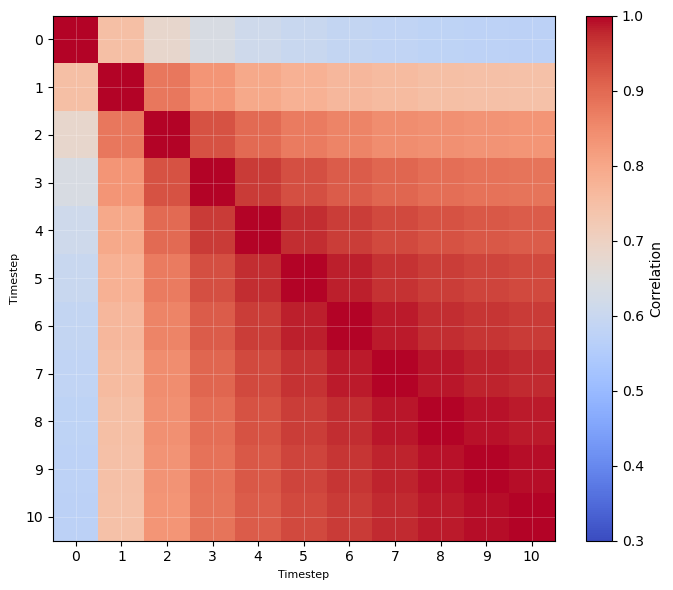

  Shape: (11, 11)
  Min: 0.5727
  Mean (off-diagonal): 0.8495


In [147]:
sm1 = compute_cosine_similarity_matrix(states_history, layer_idx=1)
plot_matrix(sm1)

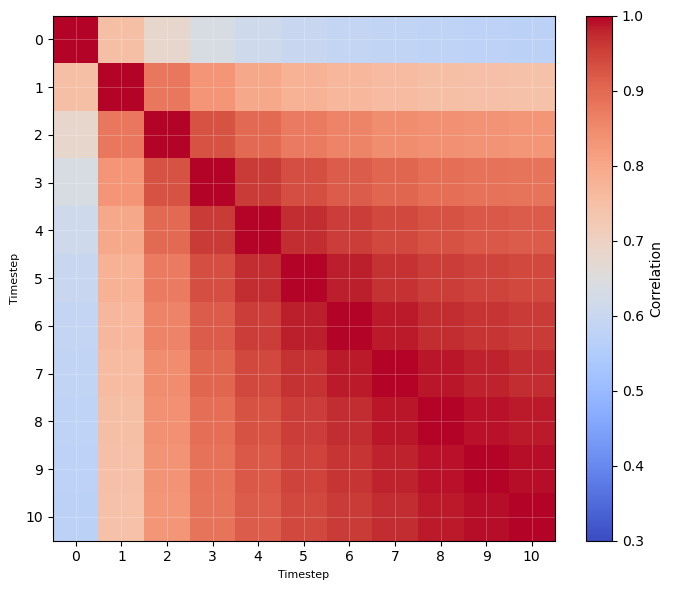

  Shape: (11, 11)
  Min: 0.5729
  Mean (off-diagonal): 0.8495


In [148]:
cm1 = compute_correlation_matrix(states_history, layer_idx=1)
plot_matrix(cm1)

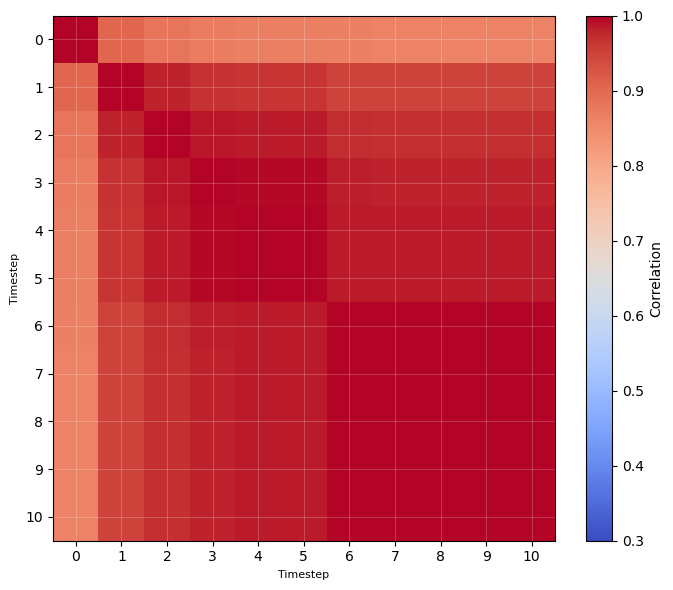

  Shape: (11, 11)
  Min: 0.8626
  Mean (off-diagonal): 0.9608


In [149]:
cm2 = compute_correlation_matrix(states_history, layer_idx=2)
plot_matrix(cm2)

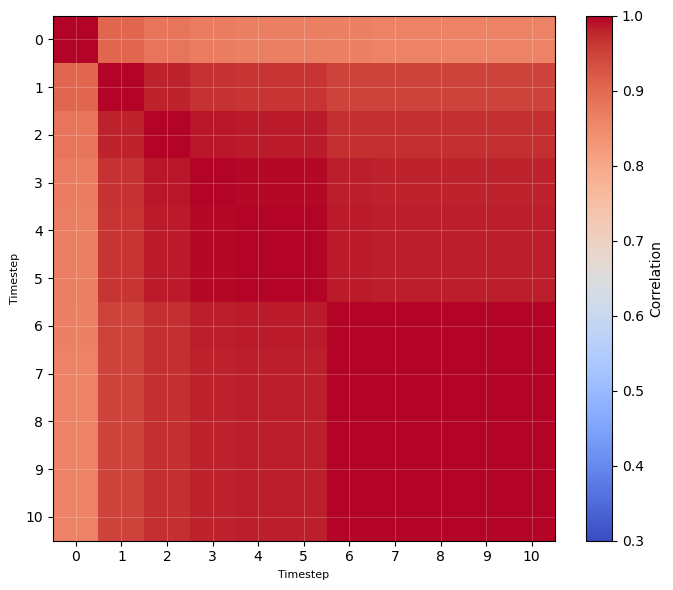

  Shape: (11, 11)
  Min: 0.8623
  Mean (off-diagonal): 0.9605


In [ ]:
sm2 = compute_cosine_similarity_matrix(states_history, layer_idx=2)
plot_matrix(sm2)

### Number of neuron flips

In [168]:
def compute_neuron_flips(states_history, layer_idx=1, batch_idx=None, percentage=False):

    n_timesteps = len(states_history)
    flips = np.zeros(n_timesteps - 1)
    
    for t in range(n_timesteps - 1):
        state_t = states_history[t].states[layer_idx]
        state_t1 = states_history[t + 1].states[layer_idx]
        
        # Flatten to (batch, features)
        s_t = state_t.reshape(state_t.shape[0], -1)
        s_t1 = state_t1.reshape(state_t1.shape[0], -1)
        
        n_neurons = s_t.shape[1]
        
        if batch_idx is not None:
            flipped = np.sum(s_t[batch_idx] != s_t1[batch_idx])
            flips[t] = (flipped / n_neurons * 100) if percentage else flipped
        else:
            flip_list = []
            for b in range(s_t.shape[0]):
                flipped = np.sum(s_t[b] != s_t1[b])
                flip_list.append((flipped / n_neurons * 100) if percentage else flipped)
            flips[t] = np.mean(flip_list)
    
    return flips


def plot_neuron_flips(flips_dict, title="Neuron Flips Over Time", figsize=(10, 5), percentage=False):

    fig, ax = plt.subplots(figsize=figsize)
    
    if isinstance(flips_dict, dict):
        for label, flips in flips_dict.items():
            ax.plot(range(len(flips)), flips, marker='o', label=label, linewidth=2)
        ax.legend()
    else:
        ax.plot(range(len(flips_dict)), flips_dict, marker='o', linewidth=2, color='blue')
    
    ax.set_xlabel('Step', fontsize=12)
    ylabel = '% of Neurons Flipped' if percentage else 'Number of Neuron Flips'
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

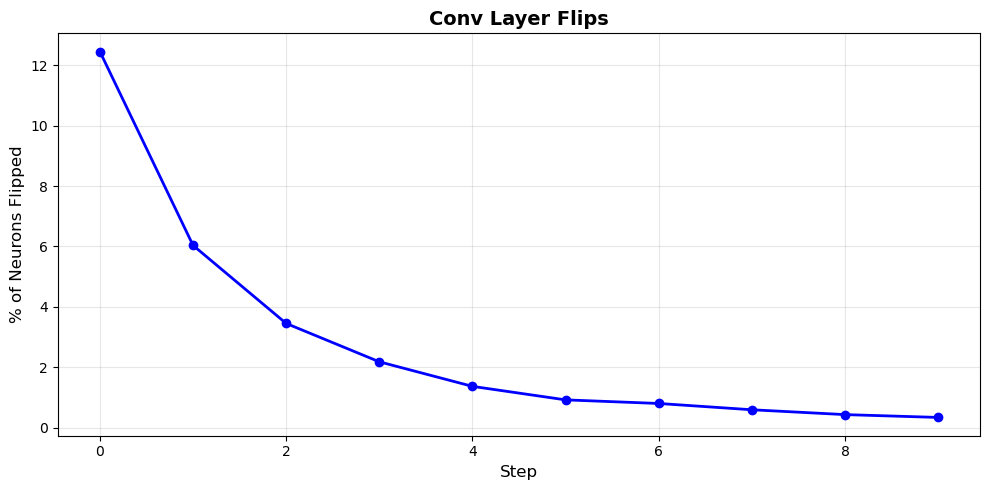

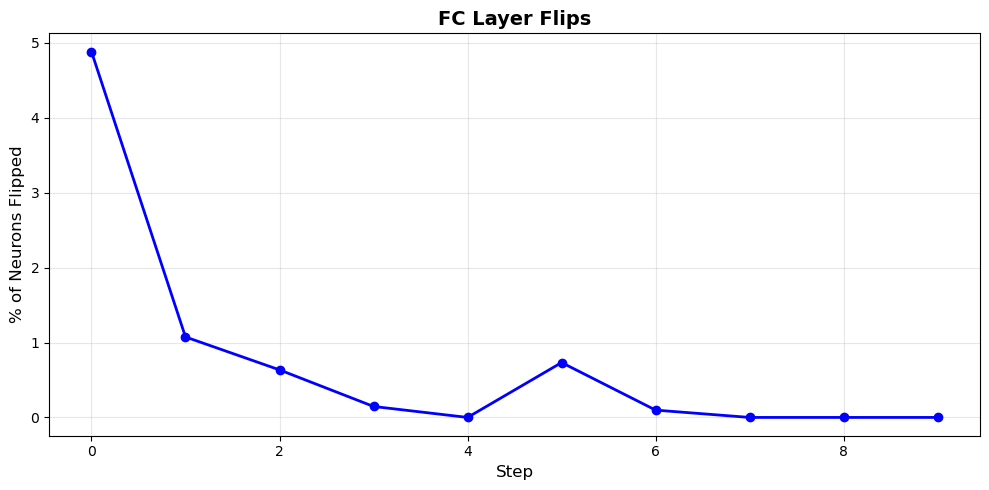

In [169]:
flips1 = compute_neuron_flips(states_history, layer_idx=1, percentage=True)
plot_neuron_flips(flips1, title="Conv Layer Flips", percentage=True)

flips2 = compute_neuron_flips(states_history, layer_idx=2, percentage=True)
plot_neuron_flips(flips2, title="FC Layer Flips", percentage=True)

## Parameter Sweep: J_d and Strength

In [160]:
def run_dynamics(x, y, j_d_conv=0.9, j_d_fc=0.9, strength_pool=1.0, strength_wout=1.0, strength_wback=1.0,
                 n_warmup=1, n_clamped=5, n_free=5, seed=42):
    """
    Build a network with given parameters, run dynamics, return states_history.
    """
    keys_test = jax.random.split(jax.random.PRNGKey(seed), 5)
    
    _input_to_hidden = Conv2D(
        in_channels=3, out_channels=N_CHANNELS, kernel_size=INPUT_KERNEL_SIZE,
        threshold=1.7, strength=1.0, key=keys_test[0], padding_mode='constant',
    )
    _recurrent_conv = Conv2DRecurrentDiscrete(
        channels=N_CHANNELS, kernel_size=RECUR_KERNEL_SIZE, groups=N_CHANNELS,
        j_d=j_d_conv, threshold=1.7, padding_mode="constant",
        key=keys_test[1], lr=1.0, weight_decay=0.0,
    )
    _pooling_forward = GlobalMajorityPooling(strength=strength_pool, axis=(1, 2))
    _unpooling_backward = GlobalUnpooling(strength=strength_pool, axis=(1, 2))
    _recurrent = RecurrentDiscrete(
        features=N_CHANNELS, j_d=j_d_fc, threshold=1.7, key=keys_test[2],
    )
    _wout = FullyConnected(
        in_features=N_CHANNELS, out_features=10,
        strength=strength_wout, threshold=1.7, key=keys_test[3],
    )
    _wback = FrozenRescaledFullyConnected(
        in_features=10, out_features=N_CHANNELS,
        strength=strength_wback, threshold=0.0, key=keys_test[4],
    )
    
    _layer_map = LayerMap.from_dict({
        1: {0: _input_to_hidden, 1: _recurrent_conv, 2: _unpooling_backward},
        2: {1: _pooling_forward, 2: _recurrent, 3: _wback},
        3: {2: _wout, 3: OutputLayer()},
    })
    _orchestrator = SequentialOrchestrator(layers=_layer_map)
    
    _state = SequentialState([(32, 32, 3), (32, 32, N_CHANNELS), (N_CHANNELS,), (10,)])
    _state = _state.init(x, y)
    
    _key, _fk = jax.random.split(jax.random.PRNGKey(seed + 1))
    _history = []
    
    for _ in range(n_warmup):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="inference")
        _history.append(_state)
    for _ in range(n_clamped):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="all")
        _history.append(_state)
    for _ in range(n_free):
        _state, _fk = _orchestrator.step(_state, rng=_fk, filter_messages="inference")
        _history.append(_state)
    
    return _history

In [164]:
def plot_correlation_row(corr_matrices, subtitles, suptitle="", figsize=(30, 10), vmin=0.3, vmax=1):
    """
    Plot a row of correlation matrices side by side.
    
    Parameters
    ----------
    corr_matrices : list of arrays
        List of correlation matrices to plot
    subtitles : list of str
        Subtitle for each plot
    suptitle : str
        Overall title for the figure
    """
    n = len(corr_matrices)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    
    for idx, (cm, subtitle) in enumerate(zip(corr_matrices, subtitles)):
        im = axes[idx].imshow(cm, cmap='coolwarm', aspect='auto', vmin=vmin, vmax=vmax)
        axes[idx].set_title(subtitle, fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Timestep', fontsize=8)
        axes[idx].set_ylabel('Timestep', fontsize=8)
        axes[idx].set_xticks(range(cm.shape[1]))
        axes[idx].set_yticks(range(cm.shape[0]))
    
    fig.colorbar(im, ax=axes, label='Correlation', shrink=0.8)
    fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_99964/563077644.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


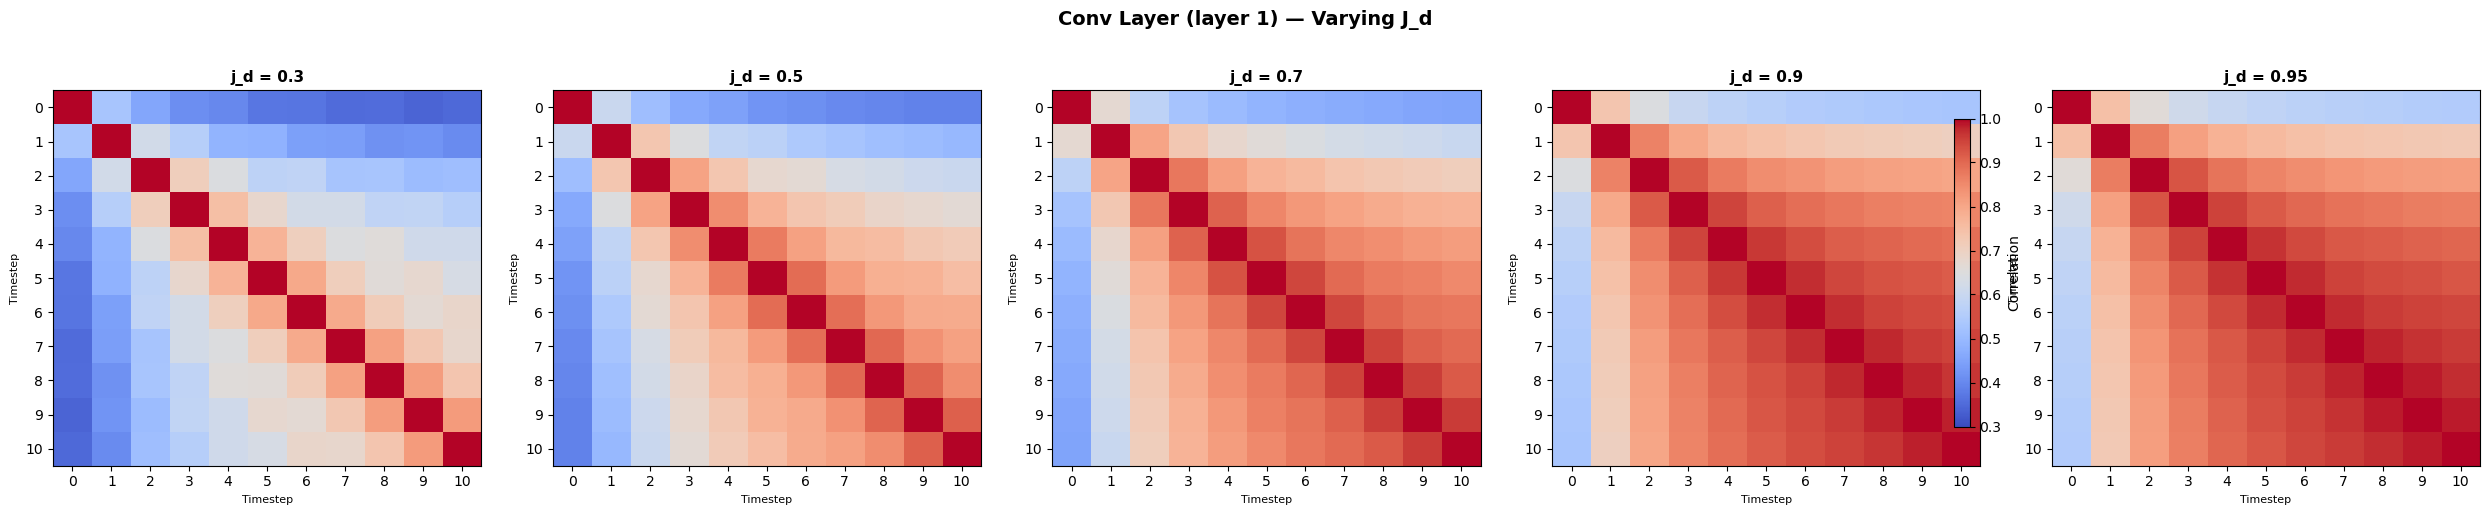

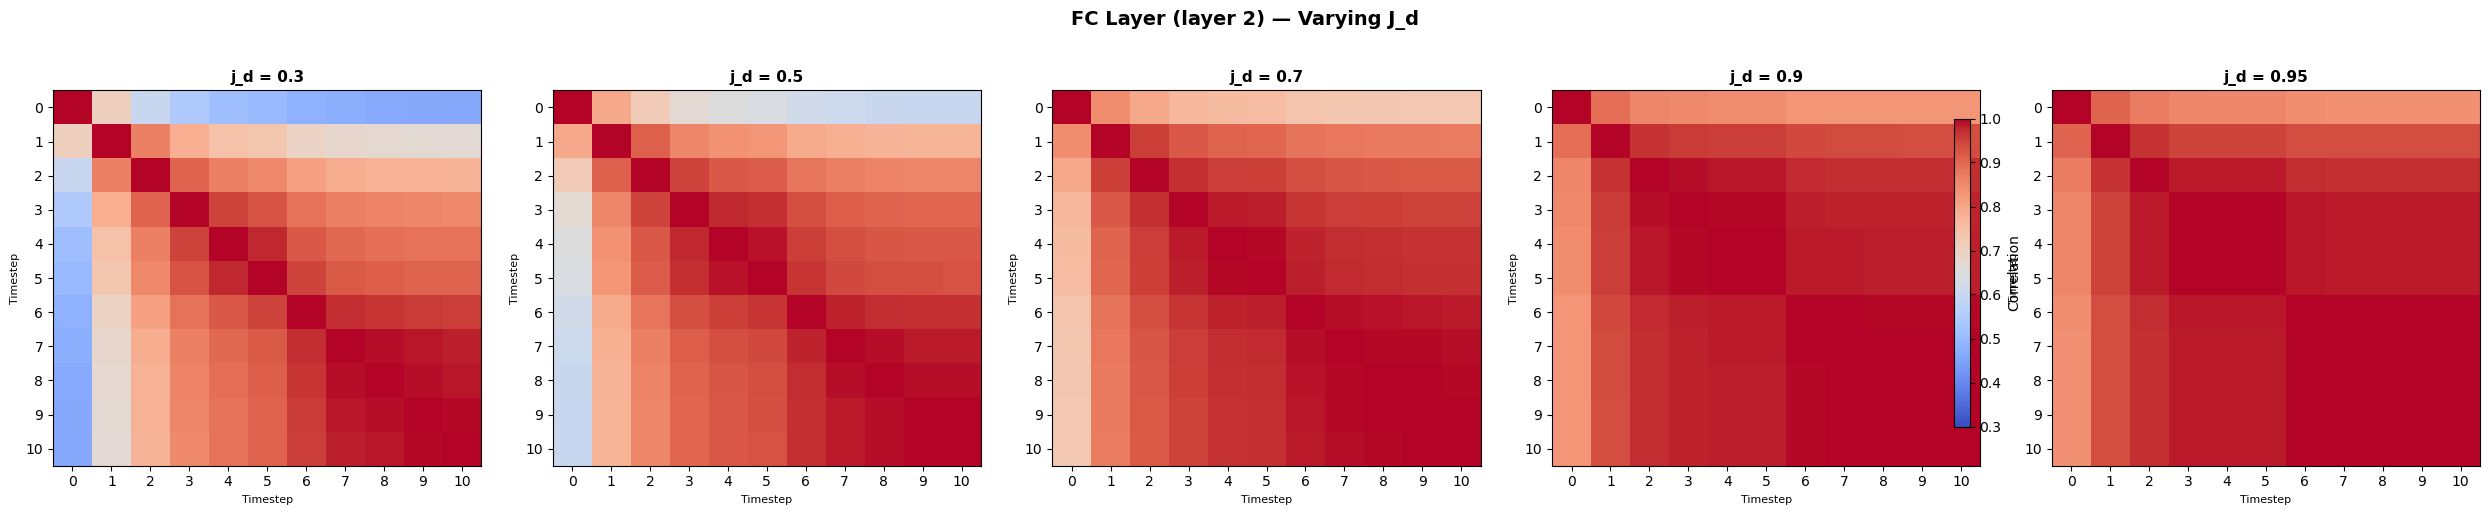

In [ ]:
# ---- Sweep over J_d ----
j_d_values = [0.3, 0.5, 0.7, 0.9, 0.95]

# Conv layer (layer 1)
corr_matrices_jd_l1 = []
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    cm = compute_correlation_matrix(history, layer_idx=1)
    corr_matrices_jd_l1.append(cm)

subtitles_jd = [f"j_d = {j}" for j in j_d_values]
plot_correlation_row(corr_matrices_jd_l1, subtitles_jd, suptitle="Conv Layer (layer 1) — Varying J_d")

# FC layer (layer 2)
corr_matrices_jd_l2 = []
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    cm = compute_correlation_matrix(history, layer_idx=2)
    corr_matrices_jd_l2.append(cm)

plot_correlation_row(corr_matrices_jd_l2, subtitles_jd, suptitle="FC Layer (layer 2) — Varying J_d")

/var/folders/d5/5853p9zd6pvbjb8vz92bhmnc0000gn/T/ipykernel_99964/563077644.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


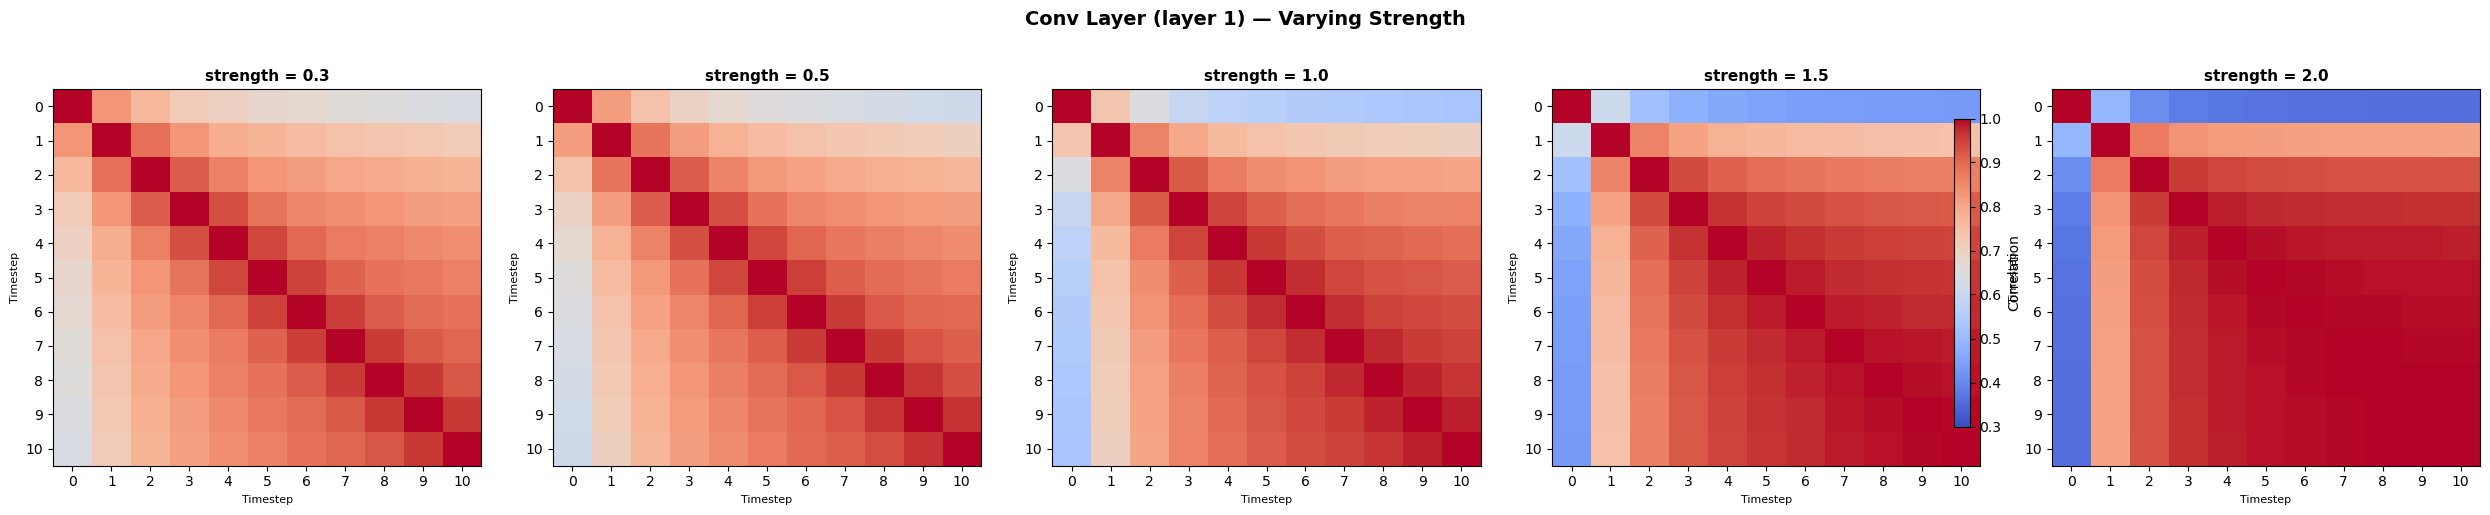

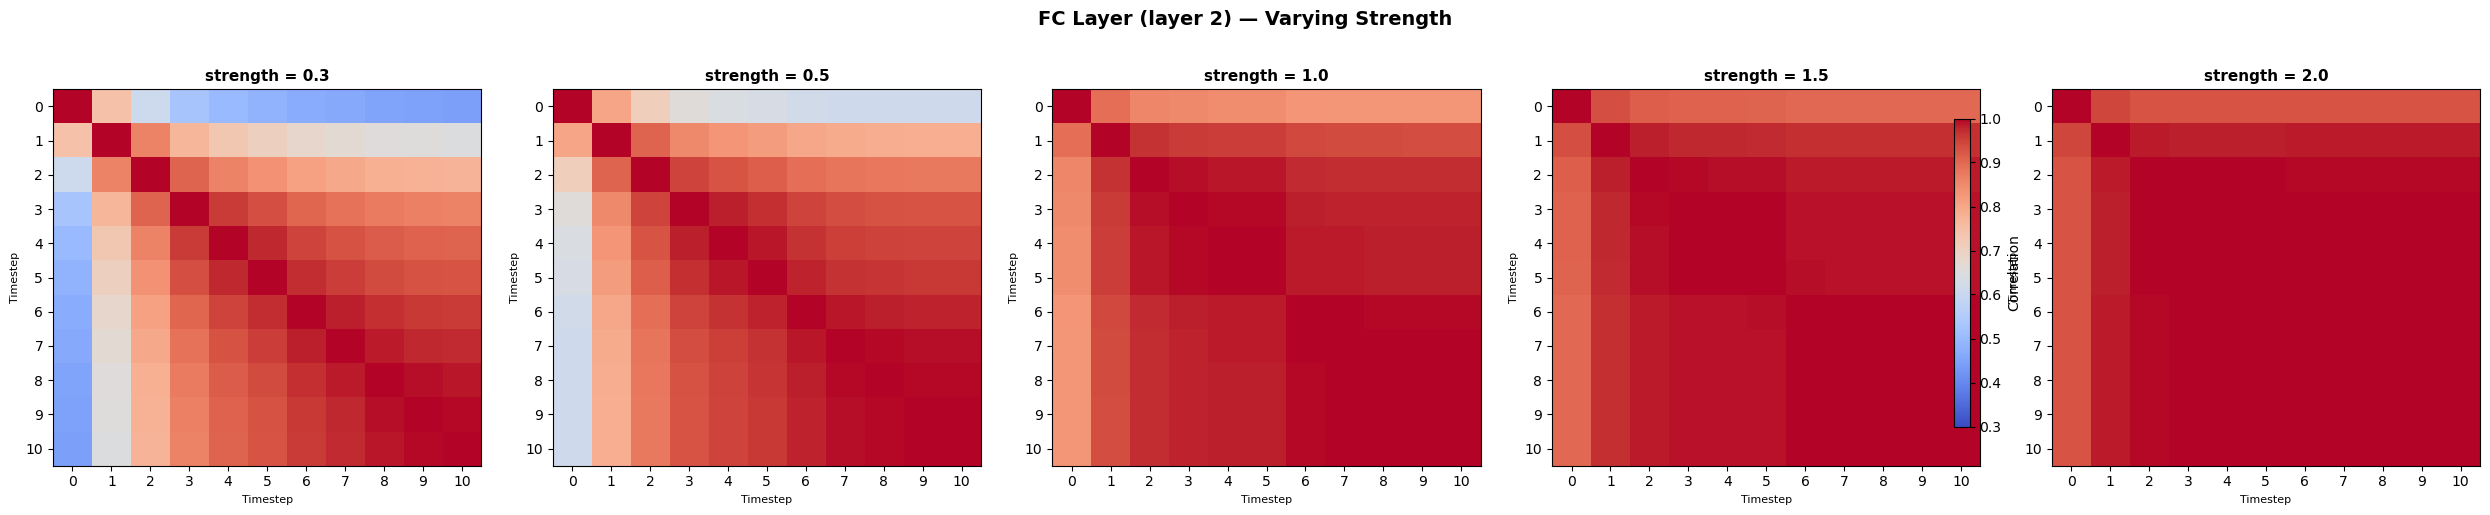

In [163]:
# ---- Sweep over strength ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]

# Conv layer (layer 1)
corr_matrices_str_l1 = []
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    cm = compute_correlation_matrix(history, layer_idx=1)
    corr_matrices_str_l1.append(cm)

subtitles_str = [f"strength = {s}" for s in strength_values]
plot_correlation_row(corr_matrices_str_l1, subtitles_str, suptitle="Conv Layer (layer 1) — Varying Strength")

# FC layer (layer 2)
corr_matrices_str_l2 = []
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    cm = compute_correlation_matrix(history, layer_idx=2)
    corr_matrices_str_l2.append(cm)

plot_correlation_row(corr_matrices_str_l2, subtitles_str, suptitle="FC Layer (layer 2) — Varying Strength")

### Neuron Flips Sweep

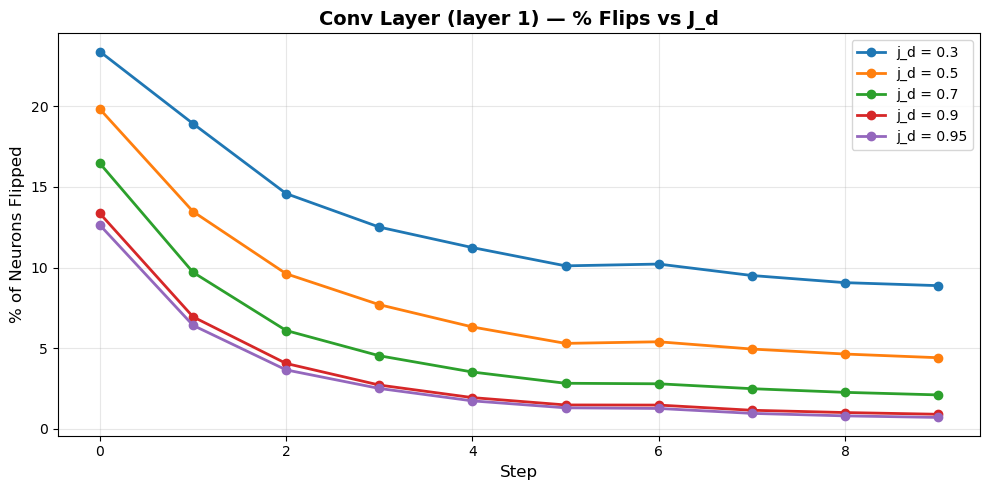

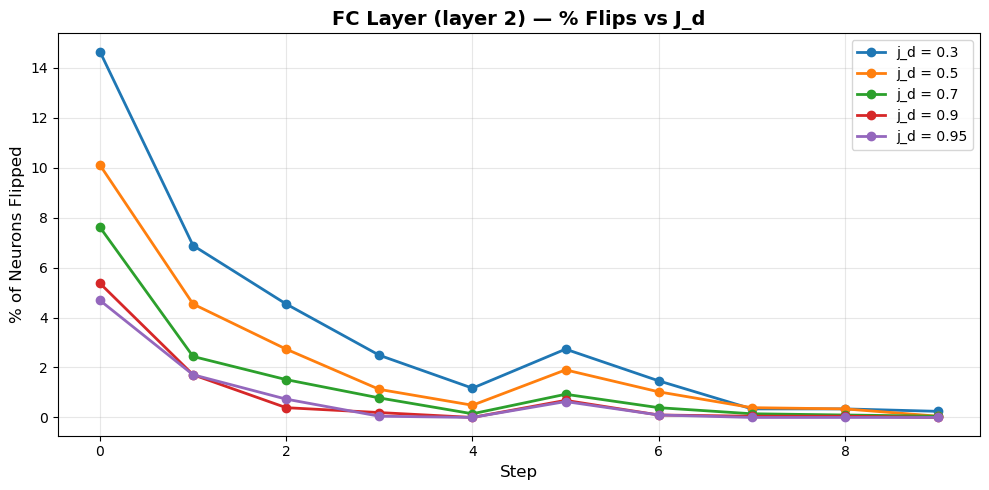

In [170]:
# ---- Neuron flips sweep over J_d ----
j_d_values = [0.3, 0.5, 0.7, 0.9, 0.95]

# Conv layer (layer 1)
flips_jd_l1 = {}
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    flips_jd_l1[f"j_d = {j_d}"] = compute_neuron_flips(history, layer_idx=1, percentage=True)

plot_neuron_flips(flips_jd_l1, title="Conv Layer (layer 1) — % Flips vs J_d", percentage=True)

# FC layer (layer 2)
flips_jd_l2 = {}
for j_d in j_d_values:
    history = run_dynamics(x, y, j_d_conv=j_d, j_d_fc=j_d)
    flips_jd_l2[f"j_d = {j_d}"] = compute_neuron_flips(history, layer_idx=2, percentage=True)

plot_neuron_flips(flips_jd_l2, title="FC Layer (layer 2) — % Flips vs J_d", percentage=True)

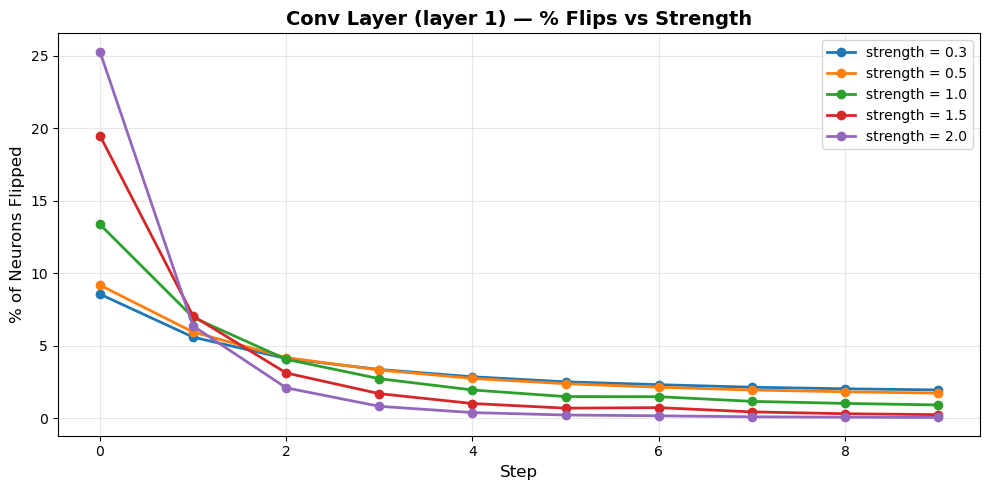

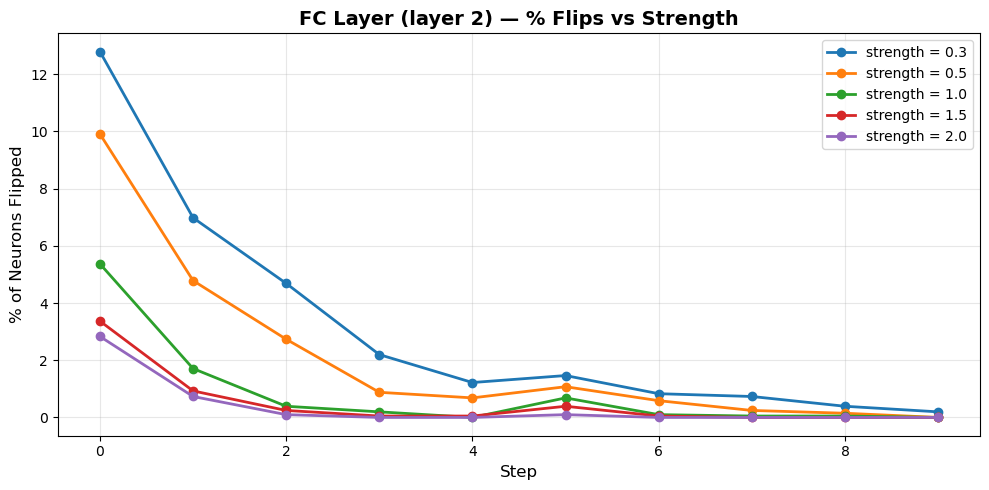

In [171]:
# ---- Neuron flips sweep over Strength ----
strength_values = [0.3, 0.5, 1.0, 1.5, 2.0]

# Conv layer (layer 1)
flips_str_l1 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    flips_str_l1[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=1, percentage=True)

plot_neuron_flips(flips_str_l1, title="Conv Layer (layer 1) — % Flips vs Strength", percentage=True)

# FC layer (layer 2)
flips_str_l2 = {}
for s in strength_values:
    history = run_dynamics(x, y, strength_pool=s, strength_wout=s, strength_wback=s)
    flips_str_l2[f"strength = {s}"] = compute_neuron_flips(history, layer_idx=2, percentage=True)

plot_neuron_flips(flips_str_l2, title="FC Layer (layer 2) — % Flips vs Strength", percentage=True)